In [5]:
#Case Study: Customer Default Prediction – Based on Decision Tree Classification Model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn import tree

In [6]:
#Data import
df = pd.read_csv('/Users/tymek/Desktop/Developer/2026-Term3-MachineLearning/SouthGermanCredit1.asc',sep=' ')
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,job,dependents,telephone,foreign_worker,default
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [7]:
# Setup CART decision trees
# Identify features and prediction target
X = df.iloc[:, 0:20]  # First 20 columns are features
y = df.iloc[:, 20]    # The 21st column (default) is the prediction target

In [8]:
#`train_test_split()` function is used to split the test and training sets, with a random state parameter of 88.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)
#Generate a decision tree, setting the maximum number of leaf nodes to 5 and the random state parameter to 88.
dtModel = DecisionTreeClassifier(max_leaf_nodes=5,random_state=88)
#Introducing the cross_val_score() function for 10-fold cross-validation
print("The results of 10-fold cross-validation：")
#Use the cross_val_score() function to obtain the model's final score.
print(cross_val_score(dtModel, X, y,cv=10 ))
dtModel.fit(X_train, y_train)

The results of 10-fold cross-validation：
[0.74 0.8  0.75 0.74 0.78 0.77 0.82 0.72 0.63 0.65]


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",88
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

[1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 1 1
 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 0 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 0 1 1 0 0 1]
0.735
[[0.28205128 0.71794872]
 [0.5505618  0.4494382 ]
 [0.13186813 0.86813187]
 [0.13186813 0.86813187]
 [0.13186813 0.86813187]]


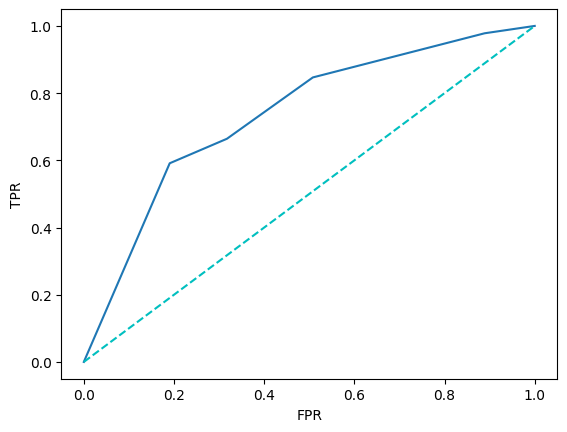

0.7374000695168579


In [9]:
#Prediction and performance assessment
y_pred = dtModel.predict(X_test)
print(y_pred[0:100])
dtModel.score(X_test, y_test)
print(dtModel.score(X_test, y_test))
y_pred_proba = dtModel.predict_proba(X_test)
print(y_pred_proba[0:5])
#Plot ROC curves
fpr, tpr, thres = roc_curve(y_test, y_pred_proba[:,1])
plt.xlabel("FPR")
plt.ylabel('TPR')
plt.plot(fpr, tpr)
#Draw a 45-degree line
plt.plot(fpr, fpr,color="c",linestyle="dashed")
plt.show()
score = roc_auc_score(y_test, y_pred_proba[:,1])
print(score)

In [10]:
# Get feature name
features = X.columns
# Obtain feature importance
importances = dtModel.feature_importances_
# Displayed in two-dimensional table format
importances_df = pd.DataFrame()
importances_df['Feature names'] = features
importances_df['Feature importances'] = importances
print(importances_df.sort_values('Feature importances', ascending=False))

           Feature names  Feature importances
0       checking_balance             0.552754
1   months_loan_duration             0.155893
5        savings_balance             0.151663
2         credit_history             0.139691
12                   age             0.000000
18             telephone             0.000000
17            dependents             0.000000
16                   job             0.000000
15      existing_credits             0.000000
14               housing             0.000000
13      installment_plan             0.000000
10     residence_history             0.000000
11              property             0.000000
9          other_debtors             0.000000
8        personal_status             0.000000
7       installment_rate             0.000000
6      employment_length             0.000000
4                 amount             0.000000
3                purpose             0.000000
19        foreign_worker             0.000000


|--- feature_0 <= 2.50
|   |--- feature_5 <= 2.50
|   |   |--- feature_2 <= 1.50
|   |   |   |--- class: 0
|   |   |--- feature_2 >  1.50
|   |   |   |--- feature_1 <= 15.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_1 >  15.50
|   |   |   |   |--- class: 0
|   |--- feature_5 >  2.50
|   |   |--- class: 1
|--- feature_0 >  2.50
|   |--- class: 1



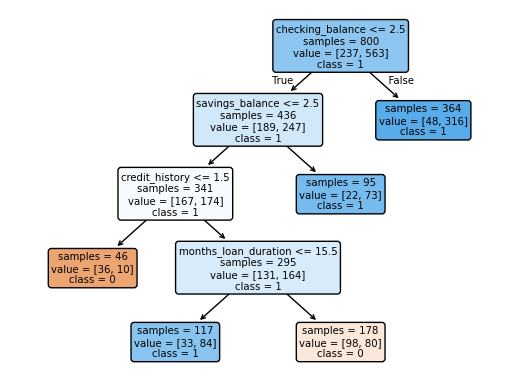

In [11]:
#Decision Tree Visualization
#Output the decision tree in text form
text_representation = tree.export_text(dtModel)
print(text_representation)

#Output decision tree as an image
tree.plot_tree(dtModel,
                    feature_names = X.columns,
                    class_names= ['0','1'],
                    rounded=True,
                    filled= True,
                    impurity=False,
                    fontsize=None)
plt.show()